E0000 00:00:1772465380.206810      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772465380.309580      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772465381.091183      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772465381.091237      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772465381.091243      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772465381.091248      55 computation_placer.cc:177] computation placer already registered. Please check linka

TensorFlow:2.19.0
GPU:/physical_device:GPU:0
Precision:float16
Status: Ready(FIXED v2)

  Train -> /kaggle/input/datasets/dwigyadav9/dataset/TRAIN.parquet
  Test  -> /kaggle/input/datasets/dwigyadav9/dataset/TEST.parquet

STEP 1->LOADING & VALIDATING DATA
Loaded in 7.4s
Train : (1428, 26001)   Test : (385, 26001)
  Label column : 'label'

  Class distribution - Train:
Background  :   322 ( 22.5%)  ======
Person      :   378 ( 26.5%)  =======
Car         :   238 ( 16.7%)  =====
Dog         :   308 ( 21.6%)  ======
Cow         :   182 ( 12.7%)  ===

  Class distribution - Test:
    Background  :    84 ( 21.8%)  ======
    Person      :    98 ( 25.5%)  =======
    Car         :    63 ( 16.4%)  ====
    Dog         :    84 ( 21.8%)  ======
    Cow         :    56 ( 14.5%)  ====
STEP 2 -> PREPROCESSING & RESHAPING
Train tensor : (1428, 500, 52, 1)
Test  tensor : (385, 500, 52, 1)

FIX 1: class_weight=None (not applied during training)
FIX 2: label_smoothing=0.01 (reduced from 0.05)


I0000 00:00:1772465422.830542      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


STEP 3 -> 2-PHASE TRAINING  (P100 GPU)


Model: "CSI_CNN_BiLSTM_FIXED"

...


--- PHASE 1: CNN FROZEN | LR=0.0003 | Epochs=15 ---
  Freezing 10 CNN/BN layers
Epoch 1/15


E0000 00:00:1772465437.904593      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/CSI_CNN_BiLSTM_FIXED_1/drop1_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1772465440.239106     132 cuda_dnn.cc:529] Loaded cuDNN version 91002


45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - accuracy: 0.2908 - auc: 0.6096 - loss: 1.6780
Epoch 1: val_accuracy improved from -inf to 0.48571, saving model to /kaggle/working/best_phase1.keras
45/45 ━━━━━━━━━━━━━━━━━━━━ 37s 391ms/step - accuracy: 0.2924 - auc: 0.6116 - loss: 1.6738 - val_accuracy: 0.4857 - val_auc: 0.8390 - val_loss: 1.1337 - learning_rate: 3.0000e-04
Epoch 2/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step - accuracy: 0.4901 - auc: 0.8312 - loss: 1.1610
Epoch 2: val_accuracy did not improve from 0.48571
45/45 ━━━━━━━━━━━━━━━━━━━━ 15s 328ms/step - accuracy: 0.4907 - auc: 0.8316 - loss: 1.1599 - val_accuracy: 0.4779 - val_auc: 0.8389 - val_loss: 1.1770 - learning_rate: 3.0000e-04
Epoch 3/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - accuracy: 0.5485 - auc: 0.8774 - loss: 1.0047
Epoch 3: val_accuracy improved from 0.48571 to 0.49870, saving model to /kaggle/working/best_phase1.keras
45/45 ━━━━━━━━━━━━━━━━━━━━ 15s 344ms/step - accuracy: 0.5491 - auc: 0.8777 - loss: 1.0034 - val

E0000 00:00:1772465643.832284      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/CSI_CNN_BiLSTM_FIXED_1/drop1_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - accuracy: 0.5002 - auc: 0.8031 - loss: 1.4338
Epoch 1: val_accuracy improved from -inf to 0.23896, saving model to /kaggle/working/best_csi_model.keras
45/45 ━━━━━━━━━━━━━━━━━━━━ 41s 483ms/step - accuracy: 0.5033 - auc: 0.8053 - loss: 1.4230 - val_accuracy: 0.2390 - val_auc: 0.5709 - val_loss: 2.2200 - learning_rate: 5.0000e-05
Epoch 2/60
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step - accuracy: 0.7972 - auc: 0.9683 - loss: 0.5769
Epoch 2: val_accuracy did not improve from 0.23896
45/45 ━━━━━━━━━━━━━━━━━━━━ 19s 430ms/step - accuracy: 0.7979 - auc: 0.9685 - loss: 0.5753 - val_accuracy: 0.1455 - val_auc: 0.5838 - val_loss: 2.4772 - learning_rate: 5.0000e-05
Epoch 3/60
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step - accuracy: 0.8954 - auc: 0.9863 - loss: 0.4225
Epoch 3: val_accuracy did not improve from 0.23896
45/45 ━━━━━━━━━━━━━━━━━━━━ 19s 428ms/step - accuracy: 0.8956 - auc: 0.9864 - loss: 0.4215 - val_accuracy: 0.1455 - val_auc: 0.6003 - val_loss: 2.59

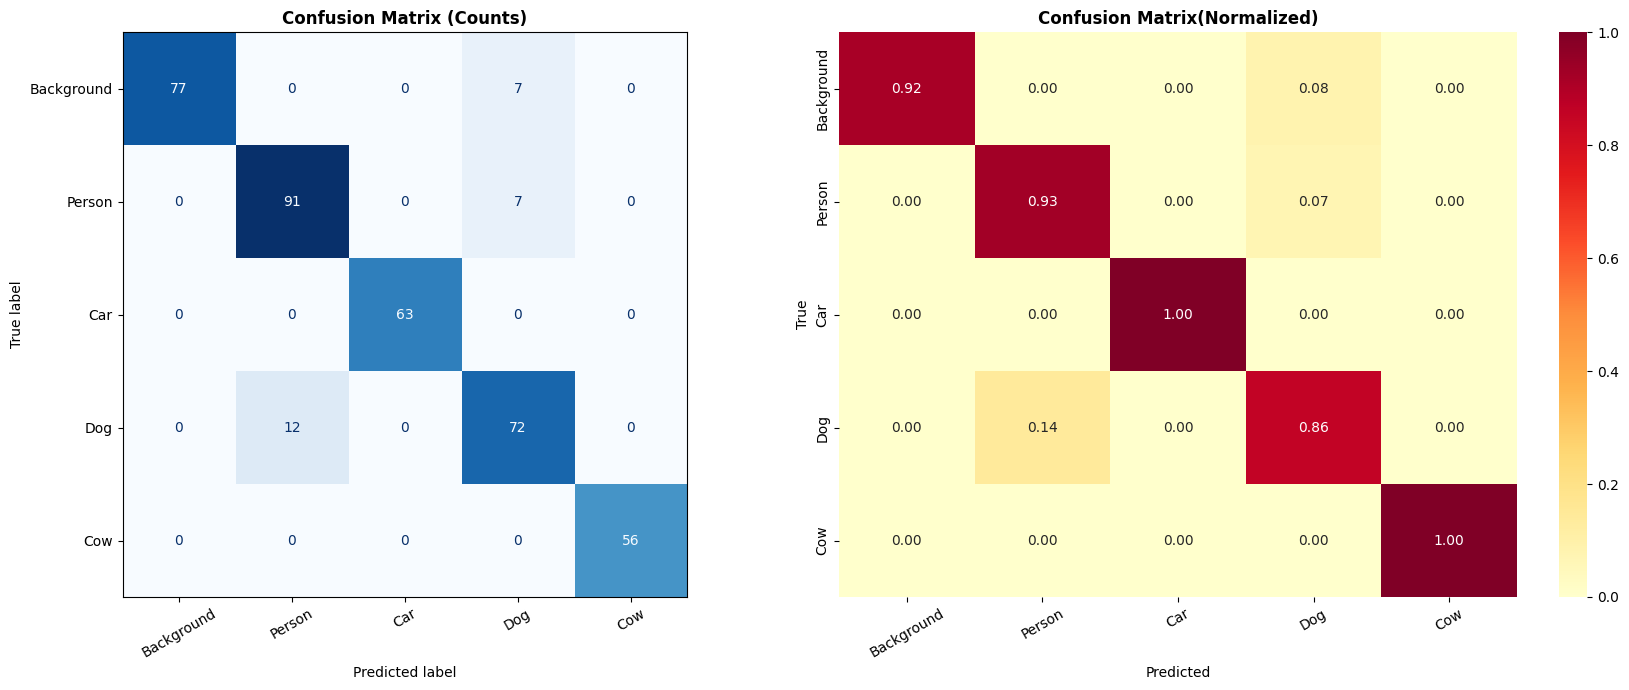

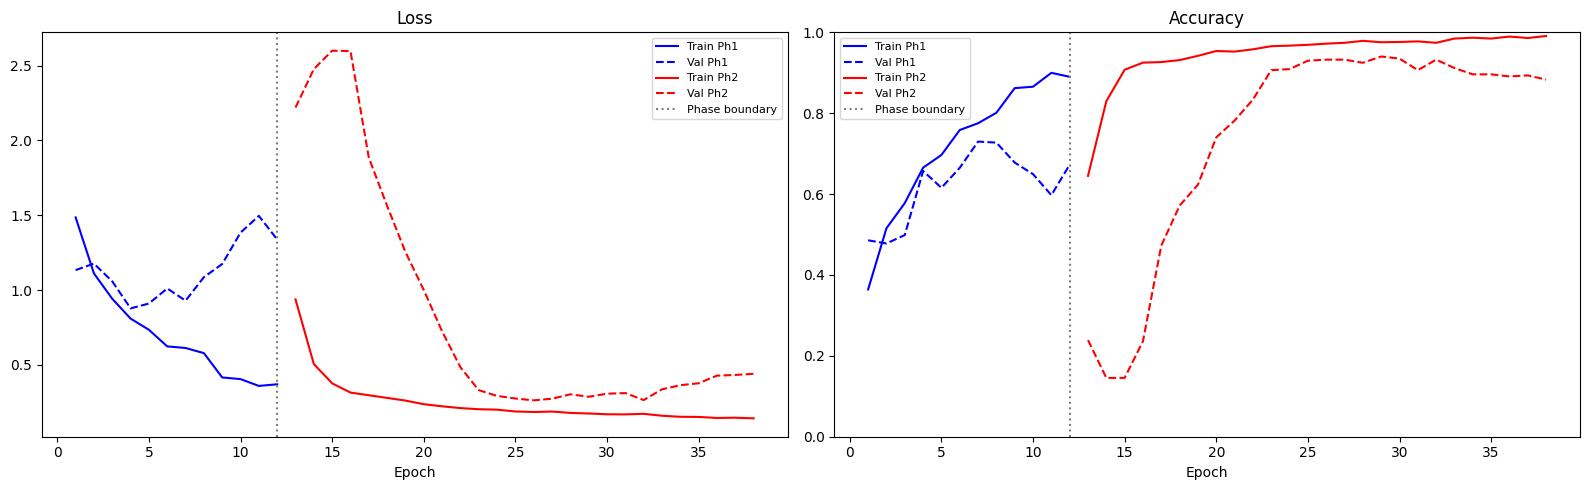

Saved->confusion_matrix.png | training_curves.png
STEP 5 -> REAL-TIME INFERENCE DEMO
   #|  Alert   | Predicted   |     True     |  Conf  |  OK 
     1 |   Clear   | Background  |  Background |0.998 | V  
     2 |   Clear   | Background  |  Background |0.999 | V  
     3 |   Clear   | Background  |  Background |0.998 | V  
     4 |   Clear   | Background  |  Background |0.998 | V  
     5 |   Clear   | Background  |  Background |0.998 | V  
     6 |   Clear   | Background  |  Background |0.998 | V  
     7 |   Clear   | Background  |  Background |0.998 | V  
     8 |   Clear   | Background  |  Background |0.998 | V  
     9 |   Clear   | Background  |  Background |0.998 | V  
    10 |   Clear   | Background  |  Background |0.998 | V  
    11 |   Clear   | Background  |  Background |0.998 | V  
    12 |   Clear   | Background  |  Background |0.999 | V  
    13 |   Clear   | Background  |  Background |0.999 | V  
    14 |   Clear   | Background  |  Background |0.999 | V  
    15 |   Clea

In [1]:
import os, sys, io, logging, warnings, re
os.environ["TF_CPP_MIN_LOG_LEVEL"]= "3"
os.environ["TF_ENABLE_ONEDNN_OPTS"]= "0"
os.environ["TF_XLA_FLAGS"] = "--tf_xla_enable_xla_devices=false"
os.environ["AUTOGRAPH_VERBOSITY"]       ="0"
os.environ["TF_FORCE_GPU_ALLOW_GROWTH"] ="true"
os.environ["CUDA_VISIBLE_DEVICES"]  = "0"
os.environ["TF_GPU_THREAD_MODE"] ="gpu_private"
os.environ["GRPC_VERBOSITY"]= "ERROR"
os.environ["GLOG_minloglevel"]= "3"
os.environ["TF_CPP_VMODULE"]="node_def_util=0"
warnings.filterwarnings("ignore")
logging.getLogger("tensorflow").setLevel(logging.FATAL)
logging.getLogger("absl").setLevel(logging.FATAL)
logging.disable(logging.WARNING)
class _FilteredStderr:
    _BLOCKED=re.compile(
        r"(NodeDef mentions|Unable to register|computation_placer|"
        r"absl::InitializeLog|TF_FORCE_GPU|cuDNN|cuBLAS|cuFFT|"
        r"use_unbounded_threadpool|MapDataset|E tensorflow|E external|"
        r"W0000|E0000|WARNING:tensorflow|WARNING:absl|meta_optimizer|"
        r"layout failed|stream_executor|NUMA node|XLA service|"
        r"Created TensorFlow device|INVALID_ARGUMENT)",
        re.IGNORECASE,
    )
    def __init__(self,original):
        self._original=original
        self._buf=""
    def write(self,text):
        self._buf+=text
        while "\n" in self._buf:
            line,self._buf= self._buf.split("\n",1)
            if not self._BLOCKED.search(line):
                self._original.write(line+"\n")
                self._original.flush()
    def flush(self):
        if self._buf and not self._BLOCKED.search(self._buf):
            self._original.write(self._buf)
            self._original.flush()
        self._buf =""
    def fileno(self):
        return self._original.fileno()
sys.stderr= _FilteredStderr(sys.__stderr__)
import random,time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks, mixed_precision
from tensorflow.keras.utils import to_categorical
tf.get_logger().setLevel("FATAL")
tf.autograph.set_verbosity(0)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import(
    classification_report,confusion_matrix,
    accuracy_score,ConfusionMatrixDisplay,
)
SEED = 42
os.environ["PYTHONHASHSEED"]=str(SEED)
os.environ["TF_DETERMINISTIC_OPS"]="1"
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
mixed_precision.set_global_policy("mixed_float16")
gpus= tf.config.list_physical_devices("GPU")
assert len(gpus)>0,"\n\nNO GPU. Fix: Settings -> Accelerator -> GPU P100\n"
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)
print("="* 55)
print(f"TensorFlow:{tf.__version__}")
print(f"GPU:{gpus[0].name}")
print(f"Precision:{mixed_precision.global_policy().compute_dtype}")
print("Status: Ready(FIXED v2)")
print("=" * 55)
BATCH_SIZE=32
EPOCHS_P1=15
EPOCHS_P2 =60
LR_P1= 3e-4
LR_P2=5e-5 
TIME_STEPS=500
SUBCARRIERS=52
TOTAL_FEATS=TIME_STEPS * SUBCARRIERS
NUM_CLASSES=5
CLASS_NAMES={0:"Background",1:"Person",2:"Car",3:"Dog",4:"Cow"}
TRAIN_PATH="/kaggle/input/datasets/dwigyadav9/dataset/TRAIN.parquet"
TEST_PATH="/kaggle/input/datasets/dwigyadav9/dataset/TEST.parquet"
if not Path(TRAIN_PATH).exists():
    TRAIN_PATH="TRAIN.parquet"
    TEST_PATH="TEST.parquet"
print(f"\n  Train -> {TRAIN_PATH}")
print(f"  Test  -> {TEST_PATH}\n")
def load_and_validate(train_path,test_path):
    print("STEP 1->LOADING & VALIDATING DATA")
    t0 = time.time()
    df_train=pd.read_parquet(train_path,engine="pyarrow")
    df_test=pd.read_parquet(test_path,engine="pyarrow")
    print(f"Loaded in {time.time()-t0:.1f}s")
    print(f"Train : {df_train.shape}   Test : {df_test.shape}")
    label_col=next(
        (c for c in ["label","class","target","y"] if c in df_train.columns),
        df_train.columns[-1]
    )
    print(f"  Label column : '{label_col}'")
    feat_cols=[c for c in df_train.columns if c != label_col]
    assert len(feat_cols)==TOTAL_FEATS,f"Expected {TOTAL_FEATS} features,got {len(feat_cols)}"
    X_train=df_train[feat_cols].values.astype(np.float32)
    y_train=df_train[label_col].values.astype(np.int32)
    X_test=df_test[feat_cols].values.astype(np.float32)
    y_test=df_test[label_col].values.astype(np.int32)
    for name,arr in [("X_train",X_train),("X_test",X_test)]:
        assert not np.any(np.isnan(arr)), f"NaN in {name}"
        assert not np.any(np.isinf(arr)), f"Inf in {name}"
    print("\n  Class distribution - Train:")
    for u, c in zip(*np.unique(y_train, return_counts=True)):
        bar="="*int(c / len(y_train) * 30)
        print(f"{CLASS_NAMES[u]:12s}: {c:5d} ({100*c/len(y_train):5.1f}%)  {bar}")
    print("\n  Class distribution - Test:")
    for u, c in zip(*np.unique(y_test, return_counts=True)):
        bar="=" * int(c / len(y_test) * 30)
        print(f"    {CLASS_NAMES[u]:12s}: {c:5d} ({100*c/len(y_test):5.1f}%)  {bar}")
    return X_train, y_train, X_test, y_test
def preprocess(X_train,y_train,X_test,y_test):
    print("STEP 2 -> PREPROCESSING & RESHAPING")
    def zscore(X):
        mu=X.mean(axis=1,keepdims=True)
        std=X.std(axis=1,keepdims=True) + 1e-8
        return (X - mu) / std
    X_train_4d=zscore(X_train).reshape(-1, TIME_STEPS, SUBCARRIERS, 1)
    X_test_4d=zscore(X_test).reshape(-1,  TIME_STEPS, SUBCARRIERS, 1)
    print(f"Train tensor : {X_train_4d.shape}")
    print(f"Test  tensor : {X_test_4d.shape}")
    y_train_cat=to_categorical(y_train, NUM_CLASSES)
    y_test_cat=to_categorical(y_test,  NUM_CLASSES)
    print("\nFIX 1: class_weight=None (not applied during training)")
    print("FIX 2: label_smoothing=0.01 (reduced from 0.05)")
    return X_train_4d, y_train_cat, X_test_4d, y_test_cat
def build_cnn_bilstm(dropout=0.3):
    inp=keras.Input(shape=(TIME_STEPS,SUBCARRIERS, 1),name="csi_input")
    x=layers.Conv2D(32,(3,3),padding="same",activation="relu",name="conv1a")(inp)
    x=layers.BatchNormalization(name="bn1a")(x)
    x=layers.Conv2D(32, (3,3), padding="same", activation="relu", name="conv1b")(x)
    x=layers.BatchNormalization(name="bn1b")(x)
    x=layers.MaxPooling2D((2,1),name="pool1")(x)
    x= layers.Dropout(dropout,name="drop1")(x)
    x = layers.Conv2D(64, (5,3),padding="same",activation="relu",name="conv2a")(x)
    x= layers.BatchNormalization(name="bn2a")(x)
    x=layers.Conv2D(64, (5,3), padding="same", activation="relu", name="conv2b")(x)
    x=layers.BatchNormalization(name="bn2b")(x)
    x=layers.MaxPooling2D((2,2), name="pool2")(x)
    x=layers.Dropout(dropout, name="drop2")(x)
    x = layers.Conv2D(128, (3,3), padding="same",activation="relu",name="conv3a")(x)
    x= layers.BatchNormalization(name="bn3a")(x)
    x =layers.MaxPooling2D((4,2), name="pool3")(x)
    x = layers.Dropout(dropout, name="drop3")(x)
    _, T, S, F = x.shape
    x = layers.Reshape((T, S * F), name="reshape")(x)
    lstm1 = layers.Bidirectional(
        layers.LSTM(256, return_sequences=True, dropout=0.2, recurrent_dropout=0.1),
        name="bilstm1")(x)
    lstm2=layers.Bidirectional(
        layers.LSTM(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.1),
        name="bilstm2")(lstm1)
    res=layers.Dense(256, name="res_proj")(lstm1)
    x=layers.Add(name="res_add")([lstm2, res])
    x=layers.LayerNormalization(name="layer_norm")(x)
    x=layers.GlobalAveragePooling1D(name="gap")(x)
    x = layers.Dense(256, activation="gelu",kernel_regularizer=regularizers.l2(1e-4),name="dense1")(x)
    x =layers.Dropout(0.3,name="drop_d1")(x)
    x =layers.Dense(128,activation="gelu",kernel_regularizer=regularizers.l2(1e-4),name="dense2")(x)
    x = layers.Dropout(0.2, name="drop_d2")(x)
    out = layers.Dense(NUM_CLASSES,activation="softmax",dtype="float32",name="output")(x)
    return keras.Model(inputs=inp, outputs=out, name="CSI_CNN_BiLSTM_FIXED")
def get_cnn_layers(model):
    return [l for l in model.layers
            if isinstance(l, (layers.Conv2D, layers.BatchNormalization))
            and l.name.startswith(("conv","bn"))]
def compile_model(model, lr):
    base_opt = keras.optimizers.AdamW(
        learning_rate=lr, weight_decay=1e-4,
        clipnorm=1.0
    )
    optimizer=mixed_precision.LossScaleOptimizer(base_opt)
    model.compile(
        optimizer=optimizer,
        loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.01),
        metrics=["accuracy", keras.metrics.AUC(name="auc", multi_label=False)],
    )
def train_model(model, X_train, y_train_cat, X_val, y_val_cat):
    print("STEP 3 -> 2-PHASE TRAINING  (P100 GPU)")
    model.summary()
    cnn_layers = get_cnn_layers(model)
    print(f"\n--- PHASE 1: CNN FROZEN | LR={LR_P1} | Epochs={EPOCHS_P1} ---")
    print(f"  Freezing {len(cnn_layers)} CNN/BN layers")
    for l in cnn_layers:
        l.trainable = False
    compile_model(model, LR_P1)
    cb1 = [
        callbacks.EarlyStopping(monitor="val_loss", patience=8,
                                restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                    patience=4, min_lr=1e-6,verbose=1),
        callbacks.ModelCheckpoint("/kaggle/working/best_phase1.keras",
                                  monitor="val_accuracy",save_best_only=True, verbose=1),
    ]
    t0=time.time()
    hist1=model.fit(
        X_train, y_train_cat,
        epochs=EPOCHS_P1,
        batch_size=BATCH_SIZE,
        validation_data=(X_val, y_val_cat),
        class_weight=None,
        callbacks=cb1,
        verbose=1,
    )
    print(f"  Phase 1 done in {(time.time()-t0)/60:.1f} min | "
          f"Best val_acc = {max(hist1.history['val_accuracy']):.4f}")
    print(f"\n--- PHASE 2: CNN UNFROZEN | LR={LR_P2} | Epochs={EPOCHS_P2} ---")
    for l in cnn_layers:
        l.trainable = True
    print(f"  Unfreezing {len(cnn_layers)} CNN/BN layers")
    compile_model(model, LR_P2)
    cb2 = [
        callbacks.EarlyStopping(monitor="val_loss", patience=12,
                                restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                    patience=6, min_lr=1e-7, verbose=1),
        callbacks.ModelCheckpoint("/kaggle/working/best_csi_model.keras",
                                  monitor="val_accuracy", save_best_only=True, verbose=1),
    ]
    t0 = time.time()
    hist2 = model.fit(
        X_train, y_train_cat,
        epochs=EPOCHS_P2,
        batch_size=BATCH_SIZE,
        validation_data=(X_val, y_val_cat),
        class_weight=None,
        callbacks=cb2,
        verbose=1,
    )
    print(f"  Phase 2 done in {(time.time()-t0)/60:.1f} min | "
          f"Best val_acc = {max(hist2.history['val_accuracy']):.4f}")
    print(f"  Best model -> /kaggle/working/best_csi_model.keras")
    return hist1, hist2
def evaluate(model, X_test, y_test, hist1, hist2):
    print("\n" + "=" * 65)
    y_prob=model.predict(X_test, batch_size=BATCH_SIZE, verbose=0)
    y_pred =np.argmax(y_prob, axis=1)
    acc=accuracy_score(y_test, y_pred)
    target_names = [CLASS_NAMES[i] for i in range(NUM_CLASSES)]
    print(f"\n  Test Accuracy : {acc*100:.2f}%\n")
    print(classification_report(y_test, y_pred, target_names=target_names))
    cm = confusion_matrix(y_test, y_pred)
    fig, axes = plt.subplots(1,2,figsize=(18, 7))
    ConfusionMatrixDisplay(cm,display_labels=target_names).plot(
        ax=axes[0],colorbar=False,cmap="Blues")
    axes[0].set_title("Confusion Matrix (Counts)",fontweight="bold")
    axes[0].tick_params(axis="x",rotation=30)
    cm_norm=cm.astype(float)/cm.sum(axis=1,keepdims=True)
    sns.heatmap(cm_norm,annot=True,fmt=".2f",cmap="YlOrRd",
                xticklabels=target_names,yticklabels=target_names, ax=axes[1])
    axes[1].set_title("Confusion Matrix(Normalized)",fontweight="bold")
    axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")
    axes[1].tick_params(axis="x",rotation=30)
    plt.tight_layout()
    plt.savefig("/kaggle/working/confusion_matrix.png", dpi=150)
    plt.show()
    e1=len(hist1.history["accuracy"])
    x1=range(1, e1 + 1)
    x2=range(e1 + 1, e1 + len(hist2.history["accuracy"]) + 1)
    fig2,ax2=plt.subplots(1,2,figsize=(16, 5))
    ax2[0].plot(x1,hist1.history["loss"],"b-",label="Train Ph1")
    ax2[0].plot(x1,hist1.history["val_loss"],"b--",label="Val Ph1")
    ax2[0].plot(x2,hist2.history["loss"],"r-",label="Train Ph2")
    ax2[0].plot(x2,hist2.history["val_loss"],"r--",label="Val Ph2")
    ax2[0].axvline(e1,color="gray",linestyle=":",label="Phase boundary")
    ax2[0].set_title("Loss"); ax2[0].set_xlabel("Epoch"); ax2[0].legend(fontsize=8)
    ax2[1].plot(x1,hist1.history["accuracy"],"b-",label="Train Ph1")
    ax2[1].plot(x1, hist1.history["val_accuracy"],"b--",label="Val Ph1")
    ax2[1].plot(x2, hist2.history["accuracy"],"r-",label="Train Ph2")
    ax2[1].plot(x2, hist2.history["val_accuracy"],"r--",label="Val Ph2")
    ax2[1].axvline(e1,color="gray",linestyle=":",label="Phase boundary")
    ax2[1].set_title("Accuracy"); ax2[1].set_xlabel("Epoch")
    ax2[1].set_ylim([0,1]); ax2[1].legend(fontsize=8)
    plt.tight_layout()
    plt.savefig("/kaggle/working/training_curves.png", dpi=150)
    plt.show()
    print("Saved->confusion_matrix.png | training_curves.png")
    return y_pred, y_prob
def realtime_demo(model,X_test_3d,y_test,n=15):
    print("STEP 5 -> REAL-TIME INFERENCE DEMO")
    print(f"{'#':>4}|{'Alert':^10}|{'Predicted':^12} | {'True':^12} | {'Conf':^6} | {'OK':^4}")
    correct = 0
    for i in range(min(n, len(X_test_3d))):
        frame = X_test_3d[i]
        mu, std = frame.mean(), frame.std() + 1e-8
        x = ((frame - mu) / std)[np.newaxis, ..., np.newaxis]
        prob=model.predict(x, verbose=0)[0]
        pred=int(np.argmax(prob))
        true=int(y_test[i])
        ok=pred==true
        correct += ok
        alert="ALERT" if pred != 0 else "Clear"
        print(f"  {i+1:>4} | {alert:^10}|{CLASS_NAMES[pred]:^12} | "
              f"{CLASS_NAMES[true]:^12}|{prob[pred]:^6.3f}|{'V' if ok else 'X':^4}")
    print(f"\n  Demo accuracy:{correct}/{n}={100*correct/n:.1f}%")
if __name__ == "__main__":
    X_train_raw, y_train, X_test_raw, y_test = \
        load_and_validate(TRAIN_PATH, TEST_PATH)
    X_train, y_train_cat, X_test, y_test_cat = \
        preprocess(X_train_raw, y_train, X_test_raw, y_test)
    model = build_cnn_bilstm(dropout=0.3)
    hist1, hist2 = train_model(
        model, X_train, y_train_cat,
        X_val=X_test, y_val_cat=y_test_cat
    )
    y_pred, y_prob = evaluate(model, X_test, y_test, hist1, hist2)
    X_test_3d = X_test.squeeze(-1)
    realtime_demo(model, X_test_3d, y_test, n=15)
    print("  ALL STEPS COMPLETE")
    print("  best_csi_model.keras  saved")
    print("  confusion_matrix.png  saved")
    print("  training_curves.png   saved")